# Power-law analysis of a single process-mining event log

This notebook performs an initial discrete power-law analysis for **one** event log
using the Python [`powerlaw`](https://github.com/jeffalstott/powerlaw) package
(Clauset–Shalizi–Newman style fitting and model comparison).

Observations are **occurrence frequencies of distinct trace variants**
(one frequency per variant). The notebook does **not** expand the data to one
row per case and does **not** treat ranks as observations.

Shared statistical helpers live in `utils.rfc.statistical_tests`. This notebook
never imports from `scripts/`.

## Environment setup (required before running)

Create and activate the Conda environment from the repository root:

```bash
conda env create -f environment.yml
conda activate process-mining-rfcs
```

If the environment already exists and you need to refresh dependencies:

```bash
conda env update -f environment.yml --prune
conda activate process-mining-rfcs
```

**Select the `process-mining-rfcs` Jupyter kernel** (not older kernels such as
`rfcs-in-process-mining`), then restart the kernel after creating or updating the
environment.

Do **not** install packages from within the notebook (no `pip install` / `conda install` cells).
`environment.yml` pins `matplotlib-inline==0.1.6` for compatibility with matplotlib 3.6.


## 0. Matplotlib / kernel compatibility check

Confirm that the active kernel uses a matplotlib / matplotlib-inline combination
compatible with this repository.


In [1]:
import sys
from importlib.metadata import version

import matplotlib

# Read matplotlib-inline version from package metadata so we never import it.
# Importing matplotlib_inline>=0.2 with matplotlib 3.6.x crashes
# (AttributeError: RcParams has no attribute '_get') before we can warn.
mpl_version_str = matplotlib.__version__
inline_version_str = version("matplotlib-inline")
mpl_version = tuple(int(part) for part in mpl_version_str.split(".")[:2])
inline_version = tuple(int(part) for part in inline_version_str.split(".")[:2])

print(f"Python: {sys.executable}")
print(f"matplotlib: {mpl_version_str}")
print(f"matplotlib-inline: {inline_version_str}")

# matplotlib-inline>=0.2 calls rcParams._get, which is absent in matplotlib 3.6.x.
if mpl_version < (3, 7) and inline_version >= (0, 2):
    raise RuntimeError(
        "Incompatible matplotlib / matplotlib-inline versions detected. "
        "You are likely on the old 'rfcs-in-process-mining' kernel. "
        "Select kernel 'process-mining-rfcs' (from environment.yml: "
        "matplotlib-inline==0.1.6 with matplotlib 3.6.x), then restart. "
        f"Current versions: matplotlib={mpl_version_str}, "
        f"matplotlib-inline={inline_version_str}."
    )

print("Matplotlib backend stack looks compatible.")


Python: c:\Users\Lennart\Tools\Miniconda\envs\process-mining-rfcs\python.exe
matplotlib: 3.6.3
matplotlib-inline: 0.1.6
Matplotlib backend stack looks compatible.


## 1. Imports and configuration

Configure the concept and log name. The default input is
`results/variants/BPIC12/attachments.csv.gz`.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import powerlaw

from utils.io import load_attachments
from utils.rfc import (
    build_summary_row,
    classify_power_law_result,
    clauset_gof_bootstrap,
    compare_power_law_alternatives,
    descriptive_frequency_stats,
    extract_frequency_counts,
    fit_discrete_power_law,
    to_frequency_array,
)

concept_name = "variants"
log_name = "BPIC12"

input_path = Path("results") / concept_name / log_name / "attachments.csv.gz"

resolved_input_path = input_path.resolve()
print(f"Resolved input path: {resolved_input_path}")

if not input_path.exists():
    raise FileNotFoundError(
        f"Attachments file not found for concept={concept_name!r}, "
        f"log={log_name!r}. Expected file at: {resolved_input_path}"
    )

print("Input file found.")


Resolved input path: C:\Users\Lennart\Documents\Workspace\process-mining-rfcs\results\variants\BPIC12\attachments.csv.gz
Input file found.


## 2. Load and inspect the attachments file

Load attachments with the existing repository helper `utils.io.load_attachments`,
then inspect the table before deriving frequencies.
In this repository, attachments files contain one row per case attachment with
`attachment_time`, `attachment_index`, and `node_id` (where `node_id` identifies
the trace variant for `concept_name="variants"`).


In [3]:
attachments_df = load_attachments(input_path)

print("Shape:", attachments_df.shape)
display(attachments_df.head())
print("Column names:", attachments_df.columns.tolist())
print("\nData types:")
display(attachments_df.dtypes.to_frame(name="dtype"))
print("Missing-value counts:")
display(attachments_df.isna().sum().to_frame(name="n_missing"))


Shape: (13087, 3)


,attachment_time,attachment_index,node_id
0,2011-10-01T08:11:46.420000+02:00,0,"('A_SUBMITTED', 'A_PARTLYSUBMITTED', 'A_DECLIN..."
1,2011-10-01T08:16:21.037000+02:00,1,"('A_SUBMITTED', 'A_PARTLYSUBMITTED', 'A_DECLIN..."
2,2011-10-01T12:09:30.362000+02:00,2,"('A_SUBMITTED', 'A_PARTLYSUBMITTED', 'A_DECLIN..."
3,2011-10-01T13:02:12.557000+02:00,3,"('A_SUBMITTED', 'A_PARTLYSUBMITTED', 'A_PREACC..."
4,2011-10-01T14:54:56.346000+02:00,4,"('A_SUBMITTED', 'A_PARTLYSUBMITTED', 'W_Afhand..."


Column names: ['attachment_time', 'attachment_index', 'node_id']

Data types:


,dtype
attachment_time,object
attachment_index,int64
node_id,object


Missing-value counts:


,n_missing
attachment_time,0
attachment_index,0
node_id,0


## 3. Derive one frequency per distinct variant

Power-law fitting requires **one occurrence frequency per distinct variant**,
not one row per case.

Use the existing helper `utils.rfc.extract_frequency_counts`, which aggregates
attachment `node_id` value counts into a one-dimensional frequency vector
(same approach as `scripts/pdf_powerlaw_analysis.py`). Wrap that vector in a
small dataframe so the frequency-column configuration and validation below stay explicit.


In [4]:
extracted_frequencies = extract_frequency_counts(attachments_df)
frequency_df = pd.DataFrame({"frequency": extracted_frequencies.astype(int)})

print(
    "Extracted variant frequencies with utils.rfc.extract_frequency_counts. "
    f"Resulting shape: {frequency_df.shape}"
)
display(frequency_df.head())


Extracted variant frequencies with utils.rfc.extract_frequency_counts. Resulting shape: (4366, 1)


,frequency
0,3429
1,1872
2,271
3,209
4,160


### Frequency-column configuration

**Edit the variable below** if your frequency table uses a different column name.


In [5]:
frequency_column = "frequency"


## 4. Validate frequencies and build the analysis array

Validate the configured column with `utils.rfc.to_frequency_array`, then obtain a
one-dimensional NumPy integer array `frequencies` (one positive integer per distinct variant).


In [6]:
frequencies = to_frequency_array(frequency_df, frequency_column=frequency_column)

print(f"Validated frequencies array: n={frequencies.size}, dtype={frequencies.dtype}")
print(f"Min={frequencies.min()}, max={frequencies.max()}")


Validated frequencies array: n=4366, dtype=int32
Min=1, max=3429


## 5. Basic descriptive statistics

Summarise the variant-frequency distribution: number of cases, number of
variants, and the concentration of rare (singleton / low-frequency) variants.


In [7]:
descriptive_stats = descriptive_frequency_stats(frequencies)
n_cases = int(descriptive_stats.loc[0, "n_cases"])
n_variants = int(descriptive_stats.loc[0, "n_variants"])
n_singletons = int(descriptive_stats.loc[0, "n_singletons"])
singleton_share = float(descriptive_stats.loc[0, "singleton_share"])

display(descriptive_stats)


,n_cases,n_variants,min_frequency,max_frequency,mean_frequency,median_frequency,n_singletons,singleton_share,n_at_most_five,at_most_five_share
0,13087,4366,1,3429,2.997481,1.0,3754,0.859826,4246,0.972515


## 6. Rank-frequency curve (RFC)

Sort frequencies in decreasing order to obtain the trace-variant rank-frequency
curve. A roughly straight appearance on log–log axes is **suggestive** of heavy
tails, but is **not** evidence of a power law. This notebook therefore does **not**
fit a linear regression in log–log space or report an $R^2$ value.


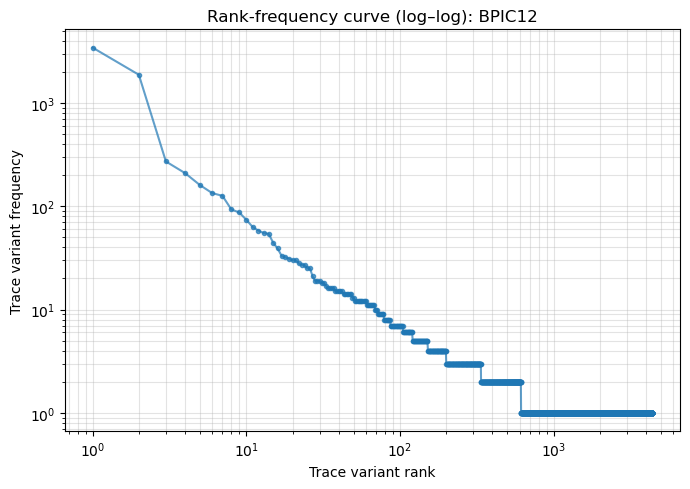

In [8]:
ranked_frequencies = np.sort(frequencies)[::-1].astype(int)
ranks = np.arange(1, ranked_frequencies.size + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ranks, ranked_frequencies, marker="o", linestyle="-", markersize=3, alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Trace variant rank")
ax.set_ylabel("Trace variant frequency")
ax.set_title(f"Rank-frequency curve (log–log): {log_name}")
ax.grid(True, which="both", alpha=0.35)
fig.tight_layout()
plt.show()


## 7. Fit a discrete power law

Fit a discrete power-law distribution to the variant frequencies with
`utils.rfc.fit_discrete_power_law` (wrapping `powerlaw.Fit`). The package estimates
the lower threshold `xmin` and the scaling exponent `alpha` for the **upper tail**
of the frequency distribution (high-frequency variants).

### Important interpretation note

In power-law terminology, the fitted “tail” is the **upper tail of the frequency
distribution**: variants that occur at least `xmin` times. In RFC space (rank on
the $x$-axis, frequency on the $y$-axis), those high-frequency variants sit at
the **left-hand head** of the curve (low ranks), **not** in the high-rank,
low-frequency long tail on the right.


In [9]:
fit_result = fit_discrete_power_law(frequencies)
fit = fit_result["fit"]
alpha = float(fit_result["alpha"])
xmin = float(fit_result["xmin"])
ks_d = float(fit_result["KS_D"])
n_fitted_variants = int(fit_result["n_fitted_variants"])
fitted_variant_share = float(fit_result["fitted_variant_share"])
fitted_case_share = float(fit_result["fitted_case_share"])

display(fit_result["summary"])


,alpha,xmin,KS_D,n_fitted_variants,fitted_variant_share,n_fitted_cases,fitted_case_share
0,2.048576,4.0,0.032244,199,0.045579,8370,0.639566


## 8. Mark the fitted region on the RFC

Highlight variants with frequency $\geq x_{\min}$ (fitted upper-frequency region)
versus variants below $x_{\min}$. A horizontal line marks $x_{\min}$.


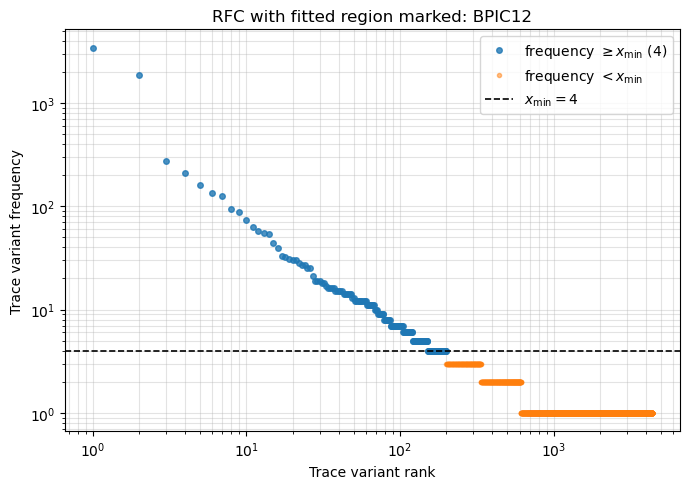

In [10]:
above_xmin_mask = ranked_frequencies >= xmin

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    ranks[above_xmin_mask],
    ranked_frequencies[above_xmin_mask],
    marker="o",
    linestyle="None",
    markersize=4,
    alpha=0.8,
    label=rf"frequency $\geq x_{{\min}}$ ({xmin:g})",
)
ax.plot(
    ranks[~above_xmin_mask],
    ranked_frequencies[~above_xmin_mask],
    marker="o",
    linestyle="None",
    markersize=3,
    alpha=0.5,
    label=rf"frequency $< x_{{\min}}$",
)
ax.axhline(xmin, color="black", linestyle="--", linewidth=1.2, label=rf"$x_{{\min}}={xmin:g}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Trace variant rank")
ax.set_ylabel("Trace variant frequency")
ax.set_title(f"RFC with fitted region marked: {log_name}")
ax.grid(True, which="both", alpha=0.35)
ax.legend()
fig.tight_layout()
plt.show()


## 9. Distribution diagnostics (PDF and CCDF)

Compare the empirical distribution in the fitted region with the fitted discrete
power law using the plotting helpers provided by `powerlaw`.


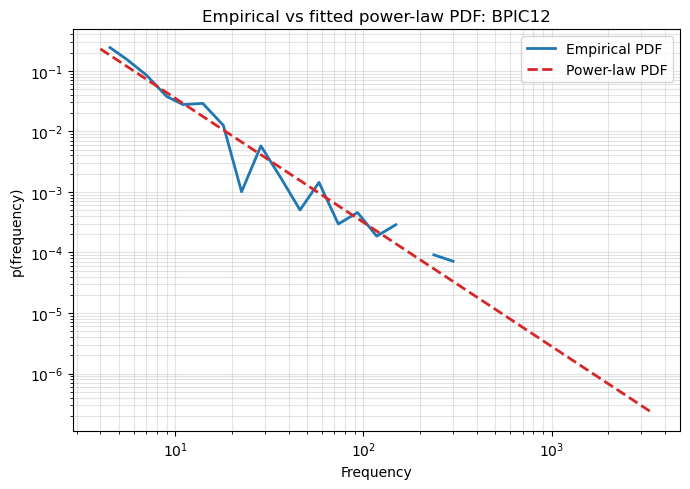

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
fit.plot_pdf(ax=ax, color="C0", linewidth=2.0, label="Empirical PDF")
fit.power_law.plot_pdf(ax=ax, color="C3", linestyle="--", linewidth=2.0, label="Power-law PDF")
ax.set_xlabel("Frequency")
ax.set_ylabel("p(frequency)")
ax.set_title(f"Empirical vs fitted power-law PDF: {log_name}")
ax.legend()
ax.grid(True, which="both", alpha=0.35)
fig.tight_layout()
plt.show()


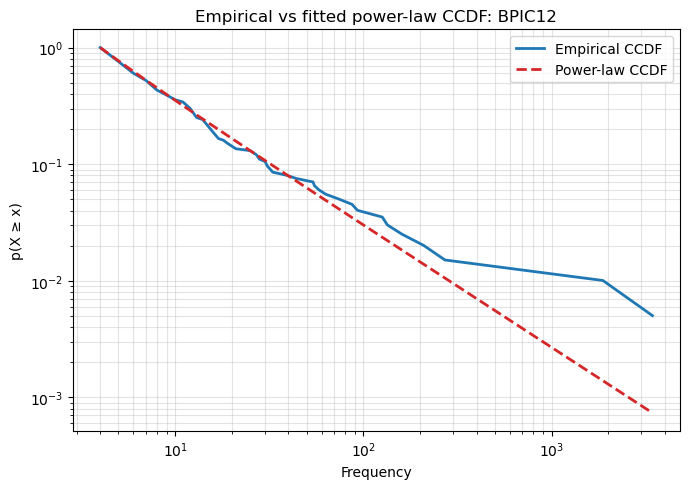

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
fit.plot_ccdf(ax=ax, color="C0", linewidth=2.0, label="Empirical CCDF")
fit.power_law.plot_ccdf(ax=ax, color="C3", linestyle="--", linewidth=2.0, label="Power-law CCDF")
ax.set_xlabel("Frequency")
ax.set_ylabel("p(X ≥ x)")
ax.set_title(f"Empirical vs fitted power-law CCDF: {log_name}")
ax.legend()
ax.grid(True, which="both", alpha=0.35)
fig.tight_layout()
plt.show()


## 10. Compare alternative distributions

Use likelihood-ratio tests (`fit.distribution_compare`, via
`utils.rfc.compare_power_law_alternatives`) to compare the power law against
lognormal, exponential, stretched exponential, and truncated power law.

Interpretation of the signed log-likelihood ratio $R$ and the comparison $p$-value:

- $R > 0$: power law is favored
- $R < 0$: the alternative is favored
- $p < 0.10$: the direction is statistically distinguishable
- $p \geq 0.10$: the comparison is inconclusive

The comparison $p$-value is **not** an absolute goodness-of-fit test for either model.


In [13]:
comparison_df = compare_power_law_alternatives(fit, log_name=log_name)
display(comparison_df)


c:\Users\Lennart\Tools\Miniconda\envs\process-mining-rfcs\lib\site-packages\powerlaw\distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
c:\Users\Lennart\Tools\Miniconda\envs\process-mining-rfcs\lib\site-packages\powerlaw\distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
c:\Users\Lennart\Tools\Miniconda\envs\process-mining-rfcs\lib\site-packages\powerlaw\distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
c:\Users\Lennart\Tools\Miniconda\envs\process-mining-rfcs\lib\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of param

,log_name,model_1,model_2,R,p,preferred_model,interpretation
0,BPIC12,power_law,lognormal,-8.117011,0.315792,lognormal,inconclusive (lognormal numerically favored)
1,BPIC12,power_law,exponential,294.405309,0.000629,power_law,power law favored (distinguishable)
2,BPIC12,power_law,stretched_exponential,2.577701,0.180238,power_law,inconclusive (power law numerically favored)
3,BPIC12,power_law,truncated_power_law,-0.000003,0.998052,truncated_power_law,inconclusive (truncated_power_law numerically ...


## 11. Clauset-style semiparametric bootstrap goodness-of-fit

The helper `utils.rfc.clauset_gof_bootstrap` implements a Clauset-style
semiparametric bootstrap goodness-of-fit test:

1. Fit the empirical frequencies and store empirical $x_{\min}$, $\alpha$, and KS distance $D$.
2. Preserve the empirical distribution below $x_{\min}$ (the “body”).
3. Generate synthetic observations at or above $x_{\min}$ from the fitted power law.
4. Combine the simulated tail with a resampled empirical body.
5. Refit each synthetic dataset, **re-estimating** $x_{\min}$.
6. Record synthetic KS distances and compute
   $p = (1 + \#\{D_{\mathrm{synth}} \geq D_{\mathrm{emp}}\}) / (n_{\mathrm{boot}} + 1)$.

Decision rule used later:

- $p < 0.10$: reject the fitted power-law hypothesis
- $p \geq 0.10$: do **not** reject the power-law hypothesis

**Failure to reject does not prove that the data follow a power law.**


In [14]:
# While developing the notebook, n_bootstraps can temporarily be reduced to 100.
n_bootstraps = 1000
random_seed = 42

gof_result = clauset_gof_bootstrap(
    frequencies,
    n_bootstraps=n_bootstraps,
    random_seed=random_seed,
)

gof_summary = pd.DataFrame(
    [
        {
            "empirical_KS_D": gof_result["empirical_d"],
            "gof_p": gof_result["gof_p"],
            "n_success": gof_result["n_success"],
            "n_failed": gof_result["n_failed"],
        }
    ]
)
display(gof_summary)

gof_p = float(gof_result["gof_p"])
if gof_p < 0.10:
    gof_interpretation = (
        "Reject the fitted power-law hypothesis at the 0.10 level."
    )
else:
    gof_interpretation = (
        "Do not reject the fitted power-law hypothesis at the 0.10 level. "
        "Failure to reject does not prove that the data follow a power law."
    )
print(gof_interpretation)


,empirical_KS_D,gof_p,n_success,n_failed
0,0.032244,0.726274,1000,0


Do not reject the fitted power-law hypothesis at the 0.10 level. Failure to reject does not prove that the data follow a power law.


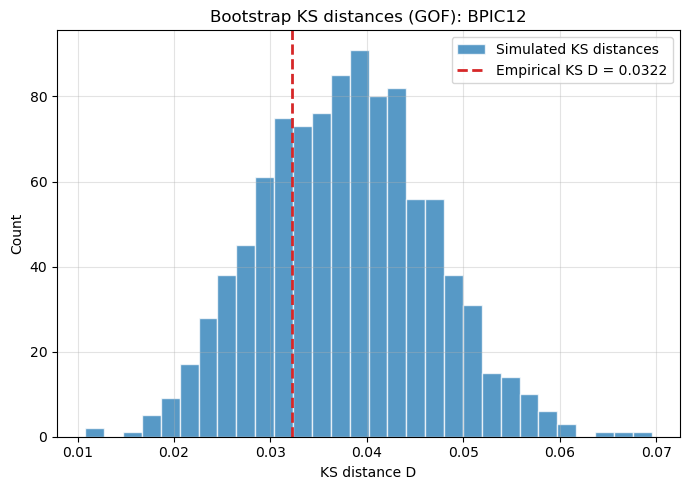

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(
    gof_result["simulated_distances"],
    bins=30,
    color="C0",
    alpha=0.75,
    edgecolor="white",
    label="Simulated KS distances",
)
ax.axvline(
    gof_result["empirical_d"],
    color="C3",
    linestyle="--",
    linewidth=2.0,
    label=f"Empirical KS D = {gof_result['empirical_d']:.4f}",
)
ax.set_xlabel("KS distance D")
ax.set_ylabel("Count")
ax.set_title(f"Bootstrap KS distances (GOF): {log_name}")
ax.legend()
ax.grid(True, alpha=0.35)
fig.tight_layout()
plt.show()


## 12. Final summary and conservative classification

Combine descriptive statistics, the power-law fit, the bootstrap GOF test, and
model comparisons into a single-row summary via `utils.rfc.build_summary_row` and
`utils.rfc.classify_power_law_result`.

Classification uses conservative rules based on:

1. whether the fitted region contains enough variants;
2. whether the GOF test rejects the power law;
3. whether any alternative is significantly preferred.


In [16]:
minimum_fitted_variants = 50
significance_level = 0.10

classification = classify_power_law_result(
    n_fitted_variants=n_fitted_variants,
    gof_p=gof_p,
    comparison_df=comparison_df,
    minimum_fitted_variants=minimum_fitted_variants,
    significance_level=significance_level,
)

summary_df = pd.DataFrame(
    [
        build_summary_row(
            concept_name=concept_name,
            log_name=log_name,
            input_path=str(input_path),
            descriptive_stats=descriptive_stats,
            fit_result=fit_result,
            gof_p=gof_p,
            classification=classification,
        )
    ]
)

print("Final summary")
display(summary_df)
print(f"\nClassification: {classification}")
print("\nModel comparisons")
display(comparison_df)


Final summary


,concept_name,log_name,input_path,n_cases,n_variants,n_singletons,singleton_share,alpha,xmin,KS_D,gof_p,n_fitted_variants,fitted_variant_share,fitted_case_share,classification
0,variants,BPIC12,results\variants\BPIC12\attachments.csv.gz,13087,4366,3754,0.859826,2.048576,4.0,0.032244,0.726274,199,0.045579,0.639566,power law plausible and preferred over alterna...



Classification: power law plausible and preferred over alternatives

Model comparisons


,log_name,model_1,model_2,R,p,preferred_model,interpretation
0,BPIC12,power_law,lognormal,-8.117011,0.315792,lognormal,inconclusive (lognormal numerically favored)
1,BPIC12,power_law,exponential,294.405309,0.000629,power_law,power law favored (distinguishable)
2,BPIC12,power_law,stretched_exponential,2.577701,0.180238,power_law,inconclusive (power law numerically favored)
3,BPIC12,power_law,truncated_power_law,-0.000003,0.998052,truncated_power_law,inconclusive (truncated_power_law numerically ...
